In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter
from lifelines.statistics import logrank_test

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# We read the dataset

In [40]:
df = pd.read_csv("../data/raw/heart_failure_clinical_records_dataset.csv")

In [42]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [103]:
df.shape

(299, 13)

We check for missing values

In [65]:
df.isna().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

We clearly do not have any missing values

So, all columns are numeric

We check if the data has duplicates rows

In [92]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


We take a look at the summary statistic

In [95]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


# We formally perform Exploratory Data Analysis

In [120]:
numeric_cols = ["age", "creatinine_phosphokinase", "ejection_fraction","platelets","serum_creatinine","serum_sodium","time" ]
categorical_cols =["anaemia","diabetes", "high_blood_pressure", "sex","smoking", "DEATH_EVENT"]

We check the distribution of "DEATH_EVENT"

In [126]:
df["DEATH_EVENT"].value_counts()

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

In [129]:
df["DEATH_EVENT"].value_counts(normalize=True)

DEATH_EVENT
0    0.67893
1    0.32107
Name: proportion, dtype: float64

There is class imbalance. Our models will likely be biased toward class 0.

In [ ]:
We present the distribution visually

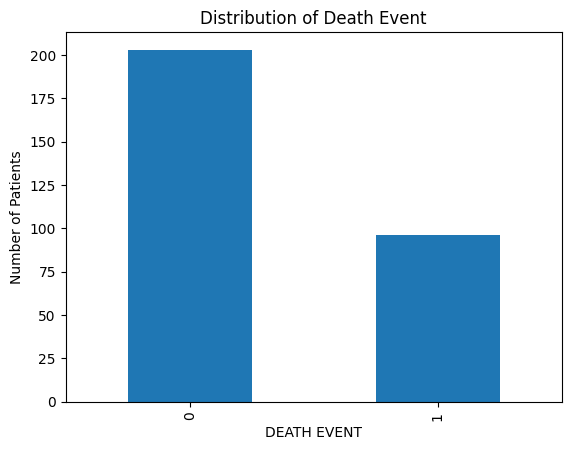

In [137]:
df["DEATH_EVENT"].value_counts().plot(kind="bar")
plt.xlabel("DEATH EVENT")
plt.ylabel("Number of Patients")
plt.title("Distribution of Death Event")
plt.show()

So, clearly Death Event = 1 is less frequent.

We visualize the distribution of the numeric columns using histogram.

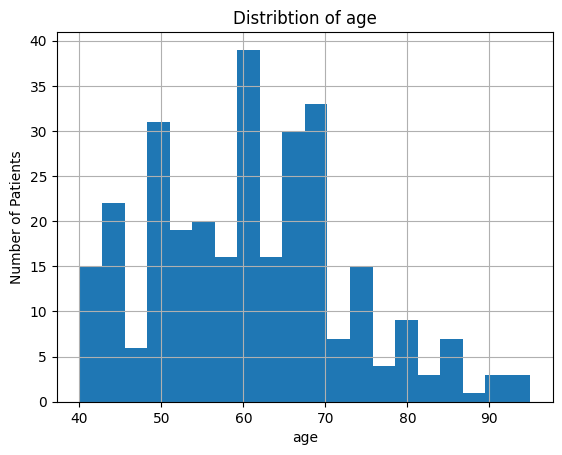

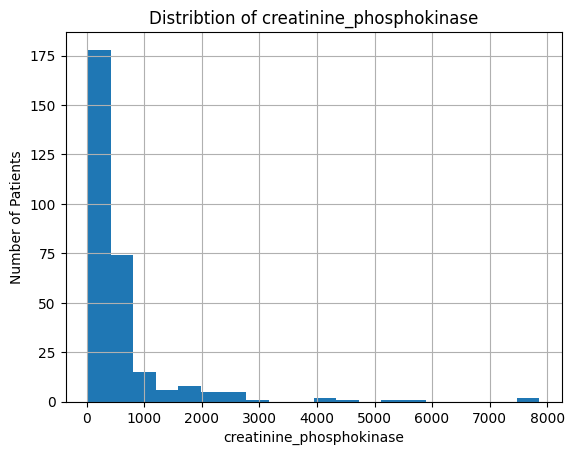

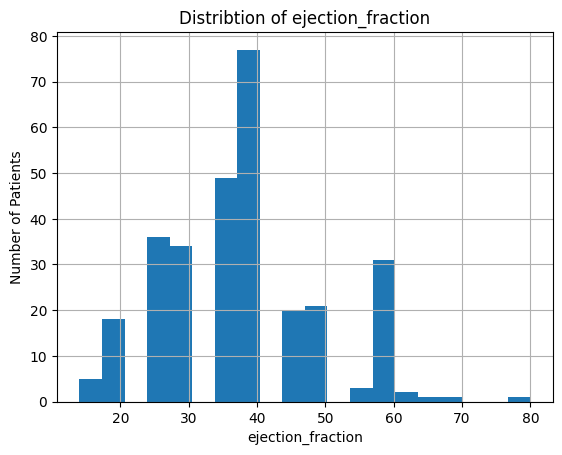

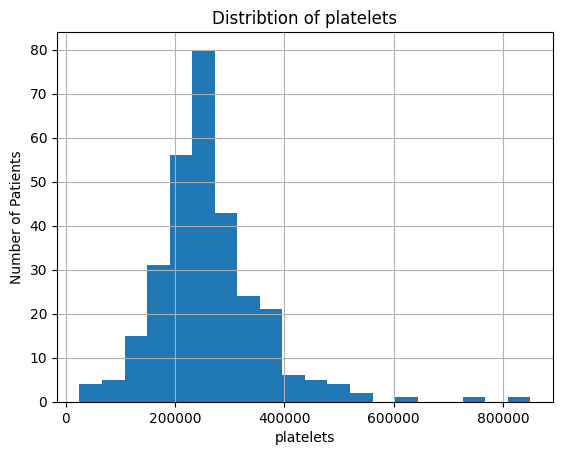

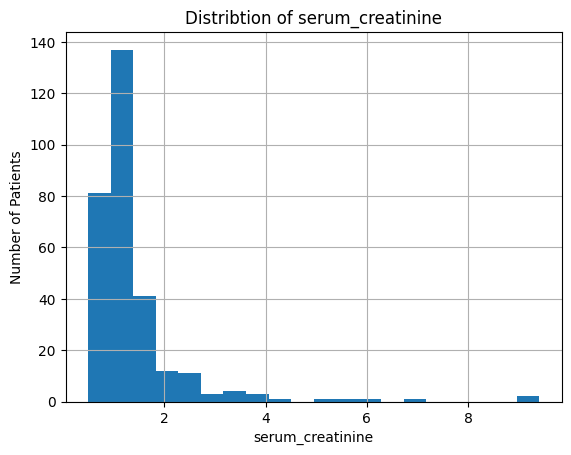

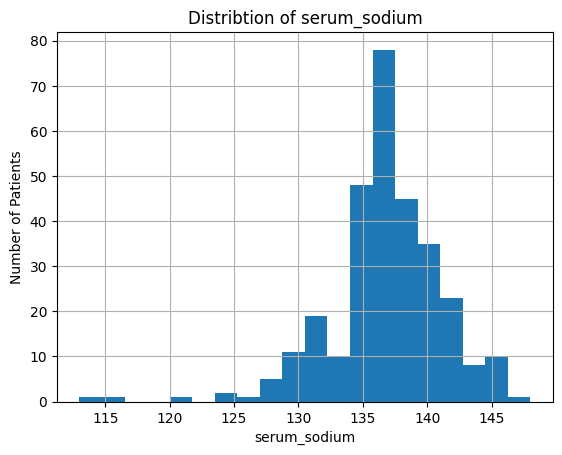

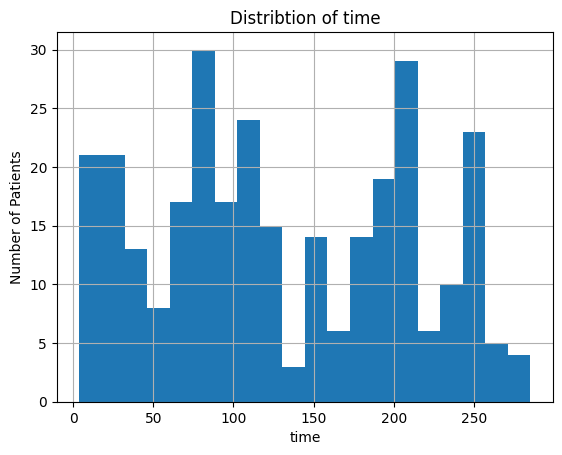

In [141]:
for col in numeric_cols:
    plt.figure()
    df[col].hist(bins=20)
    plt.xlabel(col)
    plt.ylabel("Number of Patients")
    plt.title(f"Distribtion of {col}")
    plt.show()

We can observe that creatinine_phosphokinase is skewed to the right. Majority of patients have low (less than 1000) creatinine_phosphokinase.There also seems to possible outliers.
Similarly, majority of patients have low (less than 2) serum_creatine.
Majority of patients with heart failure have high serum_sodium. The distribution of serum_sodium is approximately normal with slight left skewness.
The distribution of platelets is also approximately normal, with slight right skewness.

Next, we make plot a boxplot of the numerical variables by DEATH_EVENT.

<Figure size 640x480 with 0 Axes>

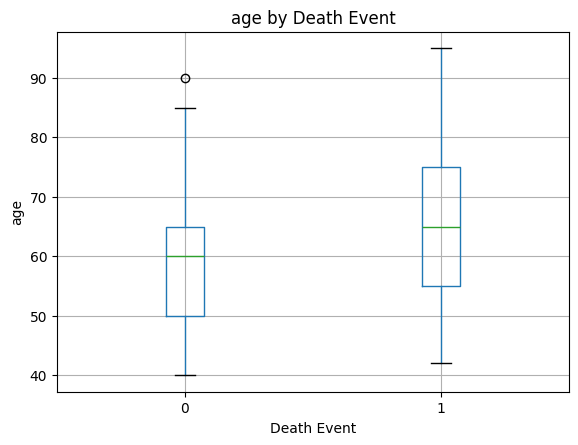

<Figure size 640x480 with 0 Axes>

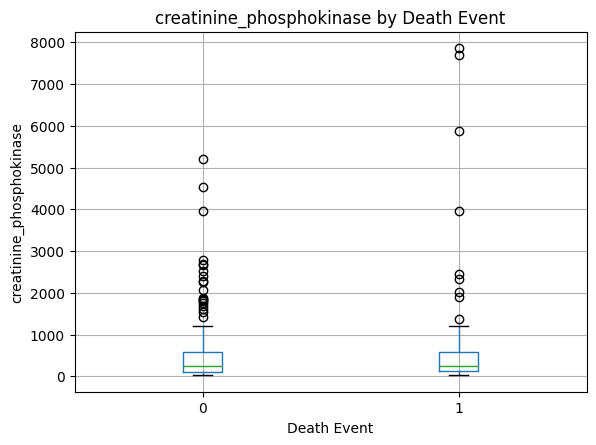

<Figure size 640x480 with 0 Axes>

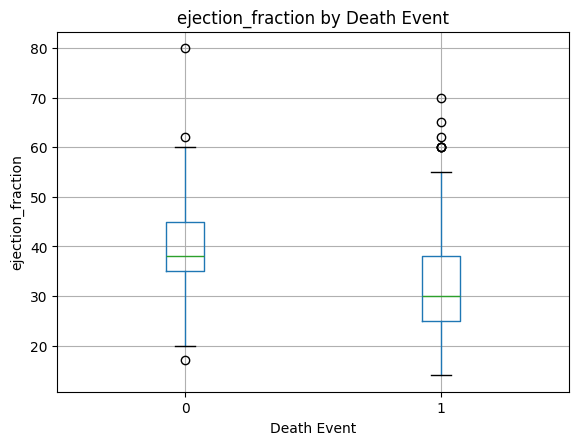

<Figure size 640x480 with 0 Axes>

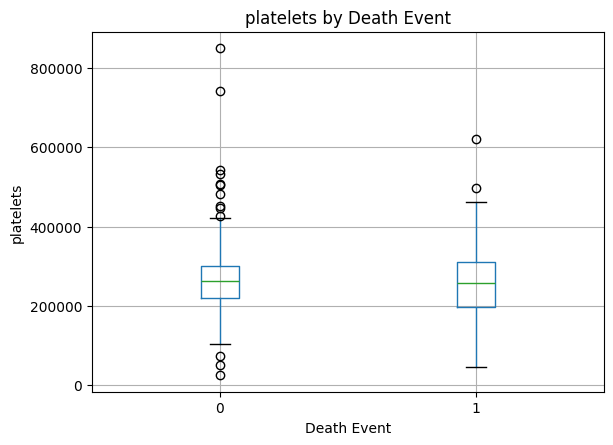

<Figure size 640x480 with 0 Axes>

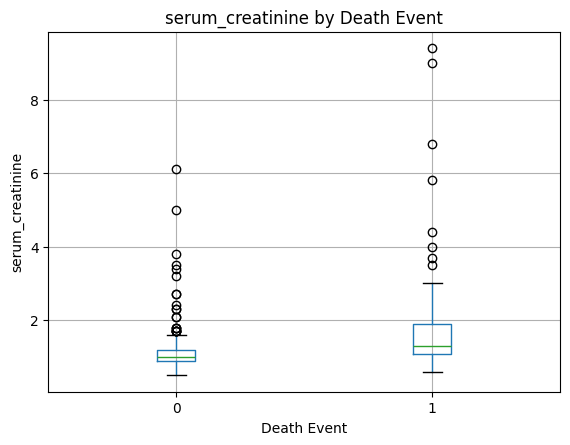

<Figure size 640x480 with 0 Axes>

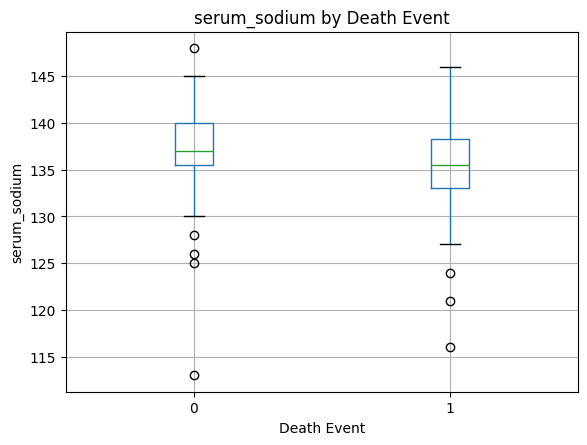

In [150]:
for col in numeric_cols:
    if col != "time":
        plt.figure()
        df.boxplot(column = col, by="DEATH_EVENT")
        plt.xlabel("Death Event")
        plt.ylabel(col)
        plt.title(f"{col} by Death Event")
        plt.suptitle("")
        plt.show()
        

The age distribution suggests that patients who experienced death event were generally older than those who survived, as shown in the higher median in the death event group . But there is also a substantial overlap between the two groups. The main boxes show that majority of patients in the two groups are between 55 and 65 years. So age alone is not sufficient to separate the two groups.

For creatinine phosphokinase distribution, we can observe a substantial overlap between the two groups. Also, the median CPK are very close in both groups. There are several outliers in both groups. So this variable alone is probably not strong enough to distinguish survival outcomes.

The distribution of ejection fraction shows that patients who experienced death events generally had lower ejection values than those who survived. The median ejection fraction is lower in the death event group, suggesting that reduced heart pumping efficiency may be associated with increased death event. There is a noticeable overlap between the two groups, which suggest that ejection fraction alone is not sufficient to fully distinguish patients who survived from those who experienced death event.


